# Microstate Parameters: Duration, Occurrence, and Coverage

This notebook computes and visualises the three **classical EEG microstate parameters** from the MPILMBB dataset:

| Parameter | Symbol | Unit |
|-----------|--------|------|
| Mean duration | $\overline{d}_k$ | ms |
| Occurrence rate | $\lambda_k$ | events s$^{-1}$ |
| Coverage | $\rho_k$ | — (fraction) |

These are extracted with `mstsa.dur_occ_cov` for four smoothing conditions derived from the method of
Pascual-Marqui et al. (1995). The smoothing window half-size $b$ controls how many neighbouring
samples contribute to each microstate assignment; larger $b$ produces smoother, longer-lasting
microstates. The files labelled `b1`, `b3`, and `b9` correspond to $b = 1, 3, 9$ samples
(window widths $2b+1 = 3, 7, 19$ samples), while `ip` denotes an alternative assignment method.

**Dataset:** MPILMBB eyes-closed resting-state EEG, $K = 4$ microstates, $f_s = 250$ Hz (4 ms / sample).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import mstsa

print(f"mstsa version: {mstsa.__version__}")

mstsa version: 0.4.0


## 1. Setup

In [2]:
data_path = Path("../data/mpilmbb")

fs = 250          # Hz  (4 ms per sample)
K  = 4            # number of microstates

conditions  = ['b1', 'b3', 'b9', 'ip']
cond_labels = {'b1': 'b = 1', 'b3': 'b = 3', 'b9': 'b = 9', 'ip': 'IP'}
ms_labels   = ['A', 'B', 'C', 'D']

subjects = sorted(set(f.name.split('_')[0] for f in data_path.glob("*.npy")))
print(f"{len(subjects)} subjects, {len(conditions)} conditions")

201 subjects, 4 conditions


## 2. Compute microstate parameters

`mstsa.dur_occ_cov(x, fs)` takes an integer microstate sequence `x` and the sampling rate `fs`,
and returns:

- `dur_dict` — a dict mapping each microstate index to the list of individual sojourn durations (ms);
- `occ` — occurrence rate array, shape `(K,)`, in events s$^{-1}$;
- `cov` — coverage array, shape `(K,)`, as a fraction of total recording time.

The first and last microstates are excluded by default because their durations are censored at the
recording boundaries.

In [3]:
results = {cond: {'dur': [], 'occ': [], 'cov': []} for cond in conditions}

for subj in subjects:
    for cond in conditions:
        fname = data_path / f"{subj}_EC_ms_{cond}_K4_ep00.npy"
        x = np.load(fname)
        dur_dict, occ, cov = mstsa.dur_occ_cov(x, fs=fs)
        mean_dur = np.array([np.mean(dur_dict[k]) for k in range(K)])
        results[cond]['dur'].append(mean_dur)
        results[cond]['occ'].append(occ)
        results[cond]['cov'].append(cov)

for cond in conditions:
    for key in ['dur', 'occ', 'cov']:
        results[cond][key] = np.array(results[cond][key])  # shape (n_subjects, K)
    print(f"{cond_labels[cond]:>6s}: {results[cond]['dur'].shape[0]} subjects")

 b = 1: 201 subjects
 b = 3: 201 subjects
 b = 9: 201 subjects
    IP: 201 subjects


## 3. Visualisation

Grouped box plots: one panel per measure, boxes grouped by microstate (A–D),
colours encoding the smoothing condition.

Since all four conditions come from the *same* subjects, differences across
conditions are tested with a repeated-measures omnibus test per microstate: a
Shapiro-Wilk check decides once per measure (not per microstate, to keep the test
consistent across all four boxes in a panel) between repeated-measures ANOVA
(if every condition's distribution is normal at every microstate) and the
non-parametric Friedman test otherwise. A bracket over each microstate's four
boxes reports the result.

In [4]:
import pandas as pd
from scipy.stats import shapiro, friedmanchisquare
from statsmodels.stats.anova import AnovaRM

measures     = ['dur', 'occ', 'cov']
ylabels      = ['Mean duration (ms)', 'Occurrence (events / s)', 'Coverage']
panel_titles = ['Duration', 'Occurrence', 'Coverage']

n_cond = len(conditions)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']  # one per condition

box_width = 0.15
offsets   = np.linspace(-(n_cond - 1) / 2, (n_cond - 1) / 2, n_cond) * box_width * 1.3
x_pos     = np.arange(K)


def sig_stars(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def effect_label(w):
    if w < 0.1:
        return 'negligible'
    if w < 0.3:
        return 'small'
    if w < 0.5:
        return 'moderate'
    return 'large'


def compare_conditions(data_by_cond, use_parametric):
    """Repeated-measures omnibus test across the (matched) conditions in
    `data_by_cond` (dict cond -> (n_subjects,) array). `use_parametric` is decided
    once per measure by the caller, not per call, so every microstate in a panel
    uses the same test. Also reports an effect size: Kendall's W for Friedman
    (stat / (n*(k-1))), partial eta-squared for RM-ANOVA (F*df1 / (F*df1+df2)) --
    both scaled 0-1, needed because with n=201 subjects even tiny, practically
    unimportant differences reach very small p-values."""
    n = len(next(iter(data_by_cond.values())))
    k = len(data_by_cond)
    if use_parametric:
        df = pd.DataFrame({
            'subject': np.tile(np.arange(n), k),
            'condition': np.repeat(list(data_by_cond.keys()), n),
            'value': np.concatenate(list(data_by_cond.values())),
        })
        aov = AnovaRM(df, 'value', 'subject', within=['condition']).fit()
        stat = aov.anova_table['F Value'].iloc[0]
        p = aov.anova_table['Pr > F'].iloc[0]
        df1 = aov.anova_table['Num DF'].iloc[0]
        df2 = aov.anova_table['Den DF'].iloc[0]
        effect = (stat * df1) / (stat * df1 + df2)
        test = 'RM-ANOVA'
    else:
        stat, p = friedmanchisquare(*data_by_cond.values())
        effect = stat / (n * (k - 1))  # Kendall's W
        test = 'Friedman'
    return dict(test=test, statistic=stat, pvalue=p, effect=effect)


alpha = 0.05
stats_results = {}
for measure in measures:
    normal_measure = all(
        shapiro(results[cond][measure][:, k]).pvalue > alpha
        for cond in conditions for k in range(K)
    )
    print(f"{measure}: {'all normal' if normal_measure else 'at least one non-normal'} "
          f"-> using {'RM-ANOVA' if normal_measure else 'Friedman'} for every microstate")
    stats_results[measure] = []
    for k in range(K):
        data_by_cond = {cond: results[cond][measure][:, k] for cond in conditions}
        res = compare_conditions(data_by_cond, normal_measure)
        stats_results[measure].append(res)
        print(f"  {ms_labels[k]}: {res['test']:>9s}  stat={res['statistic']:.3f}  "
              f"p={res['pvalue']:.4g}  {sig_stars(res['pvalue'])}   "
              f"effect={res['effect']:.3f} ({effect_label(res['effect'])})")

dur: at least one non-normal -> using Friedman for every microstate
  A:  Friedman  stat=599.454  p=1.324e-129  ***   effect=0.994 (large)
  B:  Friedman  stat=601.806  p=4.091e-130  ***   effect=0.998 (large)
  C:  Friedman  stat=600.624  p=7.381e-130  ***   effect=0.996 (large)
  D:  Friedman  stat=601.806  p=4.091e-130  ***   effect=0.998 (large)
occ: at least one non-normal -> using Friedman for every microstate
  A:  Friedman  stat=601.806  p=4.091e-130  ***   effect=0.998 (large)
  B:  Friedman  stat=597.149  p=4.182e-129  ***   effect=0.990 (large)
  C:  Friedman  stat=601.806  p=4.091e-130  ***   effect=0.998 (large)
  D:  Friedman  stat=600.624  p=7.381e-130  ***   effect=0.996 (large)
cov: at least one non-normal -> using Friedman for every microstate
  A:  Friedman  stat=318.964  p=7.816e-69  ***   effect=0.529 (large)
  B:  Friedman  stat=208.743  p=5.442e-45  ***   effect=0.346 (moderate)
  C:  Friedman  stat=47.848  p=2.294e-10  ***   effect=0.079 (negligible)
  D:  Fried

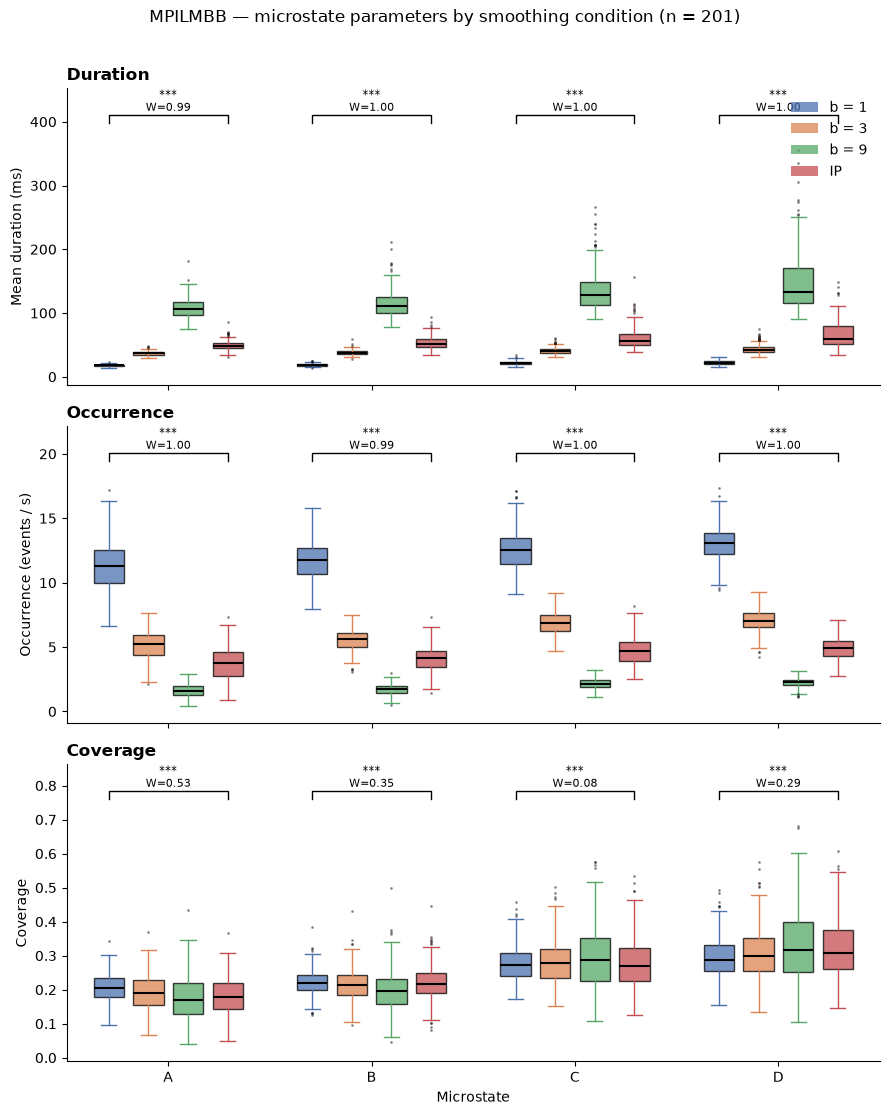

In [5]:
def add_sig_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.0, c='k')
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=8)


fig, axes = plt.subplots(3, 1, figsize=(9, 11), sharex=True)

for row, (measure, ylabel, title) in enumerate(zip(measures, ylabels, panel_titles)):
    ax = axes[row]
    for ci, cond in enumerate(conditions):
        data = results[cond][measure]        # (n_subjects, K)
        bp = ax.boxplot(
            [data[:, k] for k in range(K)],
            positions   = x_pos + offsets[ci],
            widths      = box_width,
            patch_artist= True,
            boxprops    = dict(facecolor=colors[ci], alpha=0.75),
            medianprops = dict(color='black', linewidth=1.5),
            whiskerprops= dict(color=colors[ci]),
            capprops    = dict(color=colors[ci]),
            flierprops  = dict(marker='.', markersize=2, alpha=0.4,
                               markerfacecolor=colors[ci]),
        )

    # significance bracket per microstate, spanning its 4 condition boxes
    all_vals = np.concatenate([results[cond][measure] for cond in conditions])  # (n_subj*4, K)
    ymax, ymin = all_vals.max(), all_vals.min()
    span = ymax - ymin
    bracket_y = ymax + 0.12 * span
    bracket_h = 0.04 * span
    ax.set_ylim(ymin - 0.08 * span, bracket_y + 4 * bracket_h)
    for k in range(K):
        res = stats_results[measure][k]
        label = f"{sig_stars(res['pvalue'])}\nW={res['effect']:.2f}"
        add_sig_bracket(ax, x_pos[k] + offsets[0], x_pos[k] + offsets[-1],
                         bracket_y, bracket_h, label)

    ax.set_xlim(-0.5, K - 0.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xticks(x_pos)
axes[-1].set_xticklabels(ms_labels)
axes[-1].set_xlabel('Microstate')

legend_handles = [
    mpatches.Patch(facecolor=colors[ci], alpha=0.75, label=cond_labels[cond])
    for ci, cond in enumerate(conditions)
]
axes[0].legend(handles=legend_handles, loc='upper right', frameon=False)

fig.suptitle(
    f'MPILMBB — microstate parameters by smoothing condition (n = {len(subjects)})',
    fontsize=12, y=1.01
)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig_microstate_parameters.pdf', bbox_inches='tight')
plt.show()

## 4. Group-level summary

Mean ± SD across subjects, per microstate and condition.

In [6]:
for measure, ylabel in zip(measures, ylabels):
    print(f"\n{ylabel}")
    print(f"{'Condition':>10s}  " + "  ".join(f"MS {l:>6s}" for l in ms_labels))
    print("-" * 60)
    for cond in conditions:
        data = results[cond][measure]   # (n_subjects, K)
        m = data.mean(axis=0)
        s = data.std(axis=0)
        row_str = "  ".join(f"{m[k]:6.2f}±{s[k]:.2f}" for k in range(K))
        print(f"{cond_labels[cond]:>10s}  {row_str}")


Mean duration (ms)
 Condition  MS      A  MS      B  MS      C  MS      D
------------------------------------------------------------
     b = 1   17.91±1.81   18.79±1.94   21.96±2.94   22.60±3.44
     b = 3   36.97±3.31   38.25±3.87   40.85±5.07   43.34±6.97
     b = 9  108.30±15.41  114.42±20.73  135.18±32.44  148.58±47.76
        IP   49.19±7.06   54.37±10.24   60.60±16.26   66.72±21.49

Occurrence (events / s)
 Condition  MS      A  MS      B  MS      C  MS      D
------------------------------------------------------------
     b = 1   11.35±1.86   11.74±1.43   12.61±1.57   13.06±1.34
     b = 3    5.11±1.14    5.58±0.83    6.85±0.90    7.05±0.86
     b = 9    1.59±0.52    1.73±0.43    2.16±0.44    2.24±0.37
        IP    3.75±1.24    4.11±1.01    4.68±1.05    4.93±0.83

Coverage
 Condition  MS      A  MS      B  MS      C  MS      D
------------------------------------------------------------
     b = 1    0.20±0.05    0.22±0.04    0.28±0.05    0.30±0.06
     b = 3    0.19±0.06

## 5. Lehmann et al. (2005) Syntax Test

Lehmann et al. (2005) introduced a non-parametric test of whether EEG microstates show
**non-random transition structure** (syntax). For each subject the empirical joint transition
matrix $p$ is compared against the **independence model** $q$, which gives the transition
probabilities expected if microstates appeared in random order (governed only by their
marginal frequencies). A chi-squared-type statistic

$$t = \sum_{i \neq j} \frac{(\bar{p}_{ij} - \bar{q}_{ij})^2}{\bar{q}_{ij}}$$

is computed on the group-averaged matrices and tested against a permutation null distribution
(random sign-flips of the per-subject deviations $p^{(s)} - q^{(s)}$).

`mstsa.transition_syntax_test(file_list, K, n_perm)` implements this procedure and returns the
test statistic $t$ and the 95th-percentile threshold $t_{\text{thr}}$.

**Reference:** Lehmann, D. et al. (2005). EEG microstate duration and syntax in
attention-deficit hyperactivity disorder. *Psychiatry Research: Neuroimaging*, 138, 141–152.

In [7]:
trans_results = {}
for cond in conditions:
    file_list = sorted([
        str(data_path / f"{subj}_EC_ms_{cond}_K4_ep00.npy")
        for subj in subjects
    ])
    print(f"\n{'='*40}\nCondition: {cond_labels[cond]}")
    t, t_thr = mstsa.transition_syntax_test(file_list, K=K, n_perm=5000)
    trans_results[cond] = {'t': t, 't_thr': t_thr, 'significant': t > t_thr}


Condition: b = 1
	File 201/201
Computing null distribution from random obs/exp assignments
Test statistic: 4.01e-03
Chi2 threshold: 1.97e-04
Permutation test IS significant.
Some transition rate(s) are apparently not random.

Condition: b = 3
	File 201/201
Computing null distribution from random obs/exp assignments
Test statistic: 4.57e-03
Chi2 threshold: 1.78e-04
Permutation test IS significant.
Some transition rate(s) are apparently not random.

Condition: b = 9
	File 201/201
Computing null distribution from random obs/exp assignments
Test statistic: 5.80e-03
Chi2 threshold: 2.77e-04
Permutation test IS significant.
Some transition rate(s) are apparently not random.

Condition: IP
	File 201/201
Computing null distribution from random obs/exp assignments
Test statistic: 4.35e-03
Chi2 threshold: 1.93e-04
Permutation test IS significant.
Some transition rate(s) are apparently not random.


### Group-mean transition matrices

To visualise *which* transitions are enhanced or suppressed relative to chance,
compute the group-mean observed matrix $\bar{p}$ and expected matrix $\bar{q}$
using `mstsa.embedded_process`, `mstsa.pmf`, `mstsa.tpm_joint`, and `mstsa.tpm_joint_exp`.

In [8]:
tpm_data = {}
for cond in conditions:
    p_list, q_list = [], []
    for subj in subjects:
        x = np.load(data_path / f"{subj}_EC_ms_{cond}_K4_ep00.npy")
        y, _ = mstsa.embedded_process(x)
        p_freqs = mstsa.pmf(y, K)
        p_list.append(mstsa.tpm_joint(y, K))
        q_list.append(mstsa.tpm_joint_exp(p_freqs))
    tpm_data[cond] = {
        'p_mean': np.mean(p_list, axis=0),
        'q_mean': np.mean(q_list, axis=0),
    }
    print(f"{cond_labels[cond]} done")

b = 1 done
b = 3 done
b = 9 done
IP done


### Visualisation

Top row: group-mean deviation $\bar{p} - \bar{q}$ per smoothing condition
(red = more frequent than chance, blue = less frequent; diagonal masked).
Bottom: observed test statistic $t$ vs. permutation threshold $t_{\text{thr}}$.

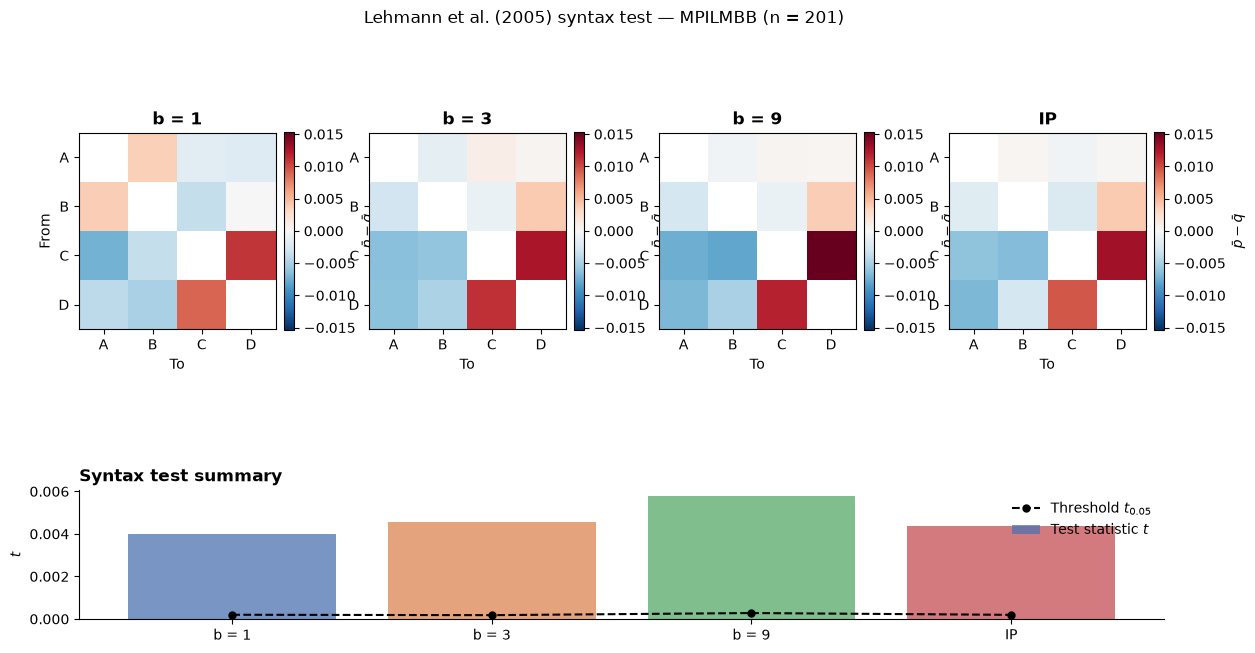

In [9]:
from matplotlib.gridspec import GridSpec

# Mask diagonal — self-transitions do not exist in the jump process
devs = {
    cond: np.ma.array(
        tpm_data[cond]['p_mean'] - tpm_data[cond]['q_mean'],
        mask=np.eye(K, dtype=bool)
    )
    for cond in conditions
}
vmax = max(np.abs(devs[cond]).max() for cond in conditions)

fig = plt.figure(figsize=(14, 7))
gs  = GridSpec(2, 4, figure=fig, height_ratios=[3.5, 1.5], hspace=0.5, wspace=0.35)

# --- Row 0: deviation heatmaps ---
for ci, cond in enumerate(conditions):
    ax = fig.add_subplot(gs[0, ci])
    im = ax.imshow(devs[cond], vmin=-vmax, vmax=vmax, cmap='RdBu_r', aspect='equal')
    ax.set_xticks(range(K)); ax.set_xticklabels(ms_labels)
    ax.set_yticks(range(K)); ax.set_yticklabels(ms_labels)
    ax.set_title(cond_labels[cond], fontweight='bold')
    if ci == 0:
        ax.set_ylabel('From')
    ax.set_xlabel('To')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r'$\bar{p} - \bar{q}$')

# --- Row 1: test statistic bar chart ---
ax_bar = fig.add_subplot(gs[1, :])
x_bar    = np.arange(len(conditions))
t_vals   = [trans_results[cond]['t']     for cond in conditions]
thr_vals = [trans_results[cond]['t_thr'] for cond in conditions]
ax_bar.bar(x_bar, t_vals, color=colors, alpha=0.75, label='Test statistic $t$')
ax_bar.plot(x_bar, thr_vals, 'k--', marker='o', markersize=5,
            label='Threshold $t_{0.05}$')
ax_bar.set_xticks(x_bar)
ax_bar.set_xticklabels([cond_labels[c] for c in conditions])
ax_bar.set_ylabel('$t$')
ax_bar.set_title('Syntax test summary', loc='left', fontweight='bold')
ax_bar.legend(frameon=False)
ax_bar.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    f'Lehmann et al. (2005) syntax test — MPILMBB (n = {len(subjects)})',
    fontsize=12
)
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig_syntax_test.pdf', bbox_inches='tight')
plt.show()